# Exploratory analysis

Craigslist used-vehicle listings, queried with **DuckDB directly against the
Parquet layers** produced by `scripts/run_all.py`. No dataframe is loaded into
memory whole: this machine has 7.7 GB of RAM and the raw CSV is 1.35 GB, so
the queries push the work into DuckDB and pull back only aggregates.

Run `python scripts/run_all.py --stages ingest,silver,gold` first.

Three findings below contradict the v1 report. Each is flagged where it appears.

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src.config import load_config

cfg = load_config(Path.cwd().parent / "conf" / "config.yaml")
ROOT = Path.cwd().parent
BRONZE = (ROOT / cfg["paths"]["bronze"] / "vehicles.parquet").as_posix()
SILVER = (ROOT / cfg["paths"]["silver"] / "**" / "*.parquet").as_posix()

con = duckdb.connect()
print(duckdb.__version__)

1.5.5


## 1. Shape, before and after cleaning

Bronze is the raw file typed and nothing else. Silver has had unusable rows
removed. The gap is the entire subject of `results/lineage.json`.

In [2]:
con.sql(f"""
    SELECT 'bronze' AS layer, count(*) AS rows FROM read_parquet('{BRONZE}')
    UNION ALL
    SELECT 'silver', count(*) FROM read_parquet('{SILVER}', hive_partitioning=true)
""").show()

┌─────────┬────────┐
│  layer  │  rows  │
│ varchar │ int64  │
├─────────┼────────┤
│ bronze  │ 426880 │
│ silver  │ 389242 │
└─────────┴────────┘



## 2. The price column is the reason cleaning exists

The maximum asking price in the raw file is **$3.7 billion**. Any mean computed
before filtering is meaningless, which is why the v1 report's stated mean price
(rendered as `$18,4421`, not a parseable number) could not be reproduced.

In [3]:
con.sql(f"""
    SELECT
        count(*)                                  AS n,
        sum(CASE WHEN price = 0 THEN 1 ELSE 0 END) AS zero_price,
        round(avg(price), 2)                      AS mean_price,
        round(median(price), 2)                   AS median_price,
        max(price)                                AS max_price
    FROM read_parquet('{BRONZE}')
""").show()

print("after cleaning:")
con.sql(f"""
    SELECT
        count(*)                AS n,
        round(avg(price), 2)    AS mean_price,
        round(median(price), 2) AS median_price,
        max(price)              AS max_price
    FROM read_parquet('{SILVER}', hive_partitioning=true)
""").show()

┌────────┬────────────┬────────────┬──────────────┬──────────────┐
│   n    │ zero_price │ mean_price │ median_price │  max_price   │
│ int64  │   int128   │   double   │    double    │    double    │
├────────┼────────────┼────────────┼──────────────┼──────────────┤
│ 426880 │      32895 │   75199.03 │      13950.0 │ 3736928711.0 │
└────────┴────────────┴────────────┴──────────────┴──────────────┘

after cleaning:
┌────────┬────────────┬──────────────┬───────────┐
│   n    │ mean_price │ median_price │ max_price │
│ int64  │   double   │    double    │  double   │
├────────┼────────────┼──────────────┼───────────┤
│ 389242 │   18819.46 │      15000.0 │  200000.0 │
└────────┴────────────┴──────────────┴───────────┘



## 3. Tier distribution — contradicts the v1 report

The v1 report states Premium is **43.1%** of the data and treats it as the
majority class. On the full cleaned dataset that is wrong: **Mid-Range** is the
largest tier and Premium is roughly ten points lower. The 43% figure came from
v1's corrupted 6,067-row sample, not from this dataset.

This matters because the majority-class baseline is the number every accuracy
figure has to be read against.

In [4]:
tiers = con.sql(f"""
    SELECT
        CASE
            WHEN price <=  8000 THEN '1 Budget'
            WHEN price <= 20000 THEN '2 Mid-Range'
            WHEN price <= 40000 THEN '3 Premium'
            ELSE                     '4 Luxury'
        END AS tier,
        count(*)                                            AS n,
        round(100.0 * count(*) / sum(count(*)) OVER (), 2)  AS pct
    FROM read_parquet('{SILVER}', hive_partitioning=true)
    GROUP BY tier ORDER BY tier
""").df()
tiers

,tier,n,pct
0,1 Budget,113479,29.15
1,2 Mid-Range,129488,33.27
2,3 Premium,118186,30.36
3,4 Luxury,28089,7.22


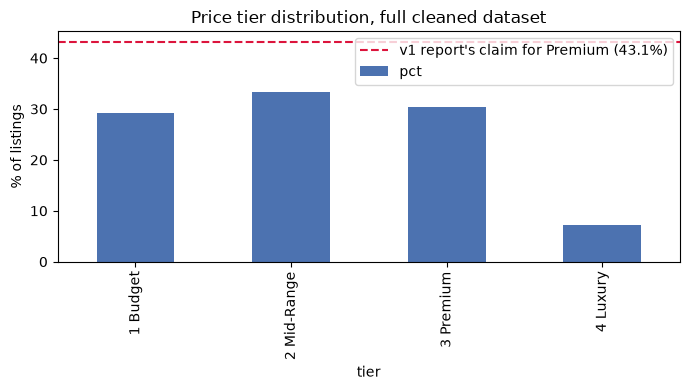

In [5]:
ax = tiers.plot.bar(x="tier", y="pct", legend=False, color="#4C72B0", figsize=(7, 4))
ax.axhline(43.1, color="crimson", ls="--", lw=1.5,
           label="v1 report's claim for Premium (43.1%)")
ax.set_ylabel("% of listings")
ax.set_title("Price tier distribution, full cleaned dataset")
ax.legend()
plt.tight_layout()

## 4. Missingness

`county` is 100% null and is dropped at bronze. The v1 report states
`paint_color` is **69.1%** missing; it is closer to 30%.

In [6]:
cols = ["county", "size", "cylinders", "condition", "VIN", "paint_color", "drive",
        "type", "manufacturer", "year", "odometer"]
parts = ",\n".join(
    f"    round(100.0 * sum(CASE WHEN \"{c}\" IS NULL THEN 1 ELSE 0 END) / count(*), 2) AS \"{c}\""
    for c in cols
)
nulls = con.sql(f"SELECT\n{parts}\nFROM read_parquet('{BRONZE}')").df().T
nulls.columns = ["pct_null"]
nulls.sort_values("pct_null", ascending=False)

,pct_null
county,100.00
size,71.77
cylinders,41.62
condition,40.79
VIN,37.73
drive,30.59
paint_color,30.50
type,21.75
manufacturer,4.13
odometer,1.03


## 5. Age against price — the v1 report has the sign backwards

The v1 report claims *"vehicle age demonstrates a strong positive correlation
(r = 0.57) with listing price, confirming expected depreciation patterns."*
A positive age-price correlation would mean older cars cost **more**, which
contradicts depreciation in the same sentence that claims to confirm it.

Computed on cleaned data, the correlation is negative, as depreciation requires.

In [7]:
con.sql(f"""
    SELECT
        round(corr(2021 - year, price), 4)   AS corr_age_price,
        round(corr(odometer, price), 4)      AS corr_odometer_price,
        round(corr(year, price), 4)          AS corr_year_price
    FROM read_parquet('{SILVER}', hive_partitioning=true)
""").show()

┌────────────────┬─────────────────────┬─────────────────┐
│ corr_age_price │ corr_odometer_price │ corr_year_price │
│     double     │       double        │     double      │
├────────────────┼─────────────────────┼─────────────────┤
│        -0.3331 │             -0.4846 │          0.3331 │
└────────────────┴─────────────────────┴─────────────────┘



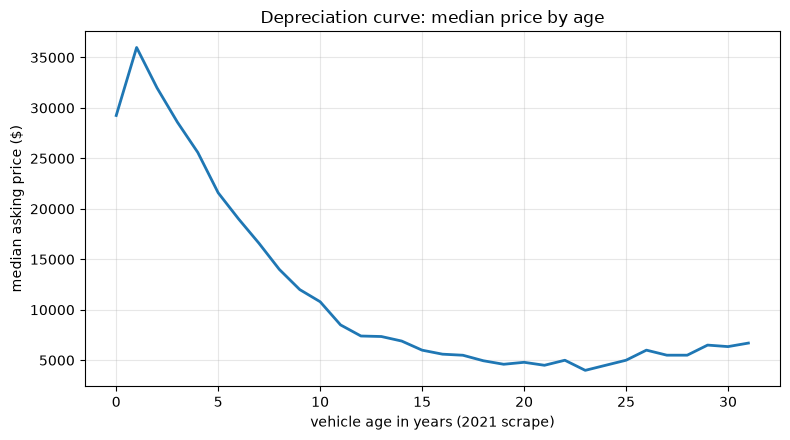

In [8]:
by_age = con.sql(f"""
    SELECT
        greatest(2021 - year, 0)  AS age,
        count(*)                  AS n,
        round(median(price), 0)   AS median_price
    FROM read_parquet('{SILVER}', hive_partitioning=true)
    WHERE year >= 1990
    GROUP BY age HAVING count(*) > 200 ORDER BY age
""").df()

ax = by_age.plot(x="age", y="median_price", legend=False, figsize=(8, 4.5), lw=2)
ax.set_xlabel("vehicle age in years (2021 scrape)")
ax.set_ylabel("median asking price ($)")
ax.set_title("Depreciation curve: median price by age")
ax.grid(alpha=0.3)
plt.tight_layout()

The curve is not monotonic. It falls steeply to roughly 20 years and then
**turns back up** as vehicles become collectible — which is why a single linear
age term underfits and why `is_vintage` earns its place as a feature.

## 6. Mileage thresholds

Price falls sharply at round-number odometer readings, which is what the binary
mileage flags in `src/features.py` are there to capture.

In [9]:
con.sql(f"""
    SELECT
        CASE
            WHEN odometer <=  30000 THEN '1 <=30k'
            WHEN odometer <=  60000 THEN '2 30-60k'
            WHEN odometer <= 100000 THEN '3 60-100k'
            WHEN odometer <= 150000 THEN '4 100-150k'
            ELSE                         '5 >150k'
        END AS mileage_band,
        count(*)                AS n,
        round(median(price), 0) AS median_price
    FROM read_parquet('{SILVER}', hive_partitioning=true)
    GROUP BY mileage_band ORDER BY mileage_band
""").show()

┌──────────────┬───────┬──────────────┐
│ mileage_band │   n   │ median_price │
│   varchar    │ int64 │    double    │
├──────────────┼───────┼──────────────┤
│ 1 <=30k      │ 77386 │      29990.0 │
│ 2 30-60k     │ 63612 │      23990.0 │
│ 3 60-100k    │ 83586 │      14999.0 │
│ 4 100-150k   │ 92735 │       9550.0 │
│ 5 >150k      │ 71923 │       6450.0 │
└──────────────┴───────┴──────────────┘



## 7. Brand tier and the Luxury problem

Luxury marques command a premium, but they are a small share of listings. This
is the imbalance that makes the Luxury tier hard to predict, and the reason
macro F1 rather than accuracy is the declared primary metric.

In [10]:
con.sql(f"""
    SELECT
        lower(trim(manufacturer))  AS brand,
        count(*)                   AS n,
        round(median(price), 0)    AS median_price,
        round(100.0 * sum(CASE WHEN price > 40000 THEN 1 ELSE 0 END) / count(*), 1)
            AS pct_luxury_tier
    FROM read_parquet('{SILVER}', hive_partitioning=true)
    WHERE manufacturer IS NOT NULL
    GROUP BY brand HAVING count(*) > 2000
    ORDER BY median_price DESC LIMIT 15
""").show()

┌───────────────┬───────┬──────────────┬─────────────────┐
│     brand     │   n   │ median_price │ pct_luxury_tier │
│    varchar    │ int64 │    double    │     double      │
├───────────────┼───────┼──────────────┼─────────────────┤
│ ram           │ 16373 │      29990.0 │            22.3 │
│ audi          │  7147 │      24795.0 │            11.1 │
│ gmc           │ 15291 │      23995.0 │            15.1 │
│ infiniti      │  4461 │      20999.0 │             2.7 │
│ lexus         │  7693 │      19971.0 │             4.1 │
│ acura         │  5681 │      19590.0 │             4.8 │
│ mercedes-benz │ 10263 │      18985.0 │            10.1 │
│ lincoln       │  4008 │      18500.0 │             7.3 │
│ jeep          │ 17327 │      17999.0 │             5.7 │
│ bmw           │ 13682 │      17995.0 │             6.5 │
│ cadillac      │  6545 │      16995.0 │             7.5 │
│ ford          │ 64316 │      16995.0 │            11.0 │
│ chevrolet     │ 50075 │      15995.0 │             9.0

## 8. Geography

Silver is partitioned by `state`, so this query reads only the partition
metadata rather than scanning the data.

In [11]:
con.sql(f"""
    SELECT state, count(*) AS n, round(median(price), 0) AS median_price
    FROM read_parquet('{SILVER}', hive_partitioning=true)
    GROUP BY state ORDER BY n DESC LIMIT 10
""").show()

┌─────────┬───────┬──────────────┐
│  state  │   n   │ median_price │
│ varchar │ int64 │    double    │
├─────────┼───────┼──────────────┤
│ ca      │ 44293 │      14950.0 │
│ fl      │ 26952 │      14900.0 │
│ tx      │ 21146 │      18500.0 │
│ ny      │ 17851 │      14995.0 │
│ oh      │ 16566 │      11992.0 │
│ mi      │ 16355 │      11304.0 │
│ or      │ 14054 │      13400.0 │
│ pa      │ 12735 │      11900.0 │
│ nc      │ 12492 │      16990.0 │
│ wa      │ 12272 │      19888.0 │
└─────────┴───────┴──────────────┘
  10 rows              3 columns



## Summary

1. **Mid-Range, not Premium, is the majority tier.** The v1 report's 43.1%
   Premium figure came from a corrupted sample. The majority-class baseline is
   correspondingly lower, and every accuracy claim must be read against it.
2. **The age-price correlation is negative.** The v1 report states it as
   positive while describing it as depreciation.
3. **`paint_color` is ~30% missing, not 69.1%.**
4. The depreciation curve reverses for vintage vehicles, so age needs
   non-linear treatment.
5. Luxury is a small minority of listings, which is the imbalance the balanced
   sample weights and the macro-F1 primary metric exist to address.

Every number here is queried live from the Parquet layers. None is transcribed.